In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_datalo = f'../data/quaia_G20.0.fits'
fn_datahi = f'../data/quaia_G20.5.fits'

fn_datalo_zbin0 = f'../data/quaia_G20.0_zsplit2bin0.fits'
fn_datalo_zbin1 = f'../data/quaia_G20.0_zsplit2bin1.fits'

fn_datahi_zbin0 = f'../data/quaia_G20.5_zsplit2bin0.fits'
fn_datahi_zbin1 = f'../data/quaia_G20.5_zsplit2bin1.fits'

fn_randlo = f'../data/randoms/random_G20.0_10x.fits'
fn_randhi = f'../data/randoms/random_G20.5_10x.fits'

fn_randlo_zbin0 = f'../data/randoms/random_G20.0_zsplit2bin0_10x.fits'
fn_randlo_zbin1 = f'../data/randoms/random_G20.0_zsplit2bin1_10x.fits'

fn_randhi_zbin0 = f'../data/randoms/random_G20.5_zsplit2bin0_10x.fits'
fn_randhi_zbin1 = f'../data/randoms/random_G20.5_zsplit2bin1_10x.fits'

In [4]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

In [5]:
fn_sello_zbin0 = f'../data/maps/selection_function_NSIDE64_G20.0_zsplit2bin0.fits'
fn_sello_zbin1 = f'../data/maps/selection_function_NSIDE64_G20.0_zsplit2bin1.fits'

fn_selhi_zbin0 = f'../data/maps/selection_function_NSIDE64_G20.5_zsplit2bin0.fits'
fn_selhi_zbin1 = f'../data/maps/selection_function_NSIDE64_G20.5_zsplit2bin1.fits'

## Parameters

In [6]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [7]:
G_hi = 20.5
G_lo = 20.0

In [8]:
nthreads = 18

In [9]:
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

In [10]:
selfunc_hi_zbin0 = hp.fitsfunc.read_map(fn_selhi_zbin0)
selfunc_hi_zbin1 = hp.fitsfunc.read_map(fn_selhi_zbin1)

In [11]:
mask_type = 'selfunc'

# Visuals

In [12]:
tab_datalo, pixel_indices_datalo_mask, N_datalo_mask, mask_datalo = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, mask_type = 'selfunc')

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [13]:
cmap_reds = sns.color_palette("Reds_r", as_cmap = True)
cmap_blues = sns.color_palette("Blues_r", as_cmap = True)

In [14]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [15]:
z_array = [0,1]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(z_array)))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_red, cmap_blue]

In [16]:
blue = np.mean(cmap_blue, axis = 0)
red = np.mean(cmap_red, axis = 0)

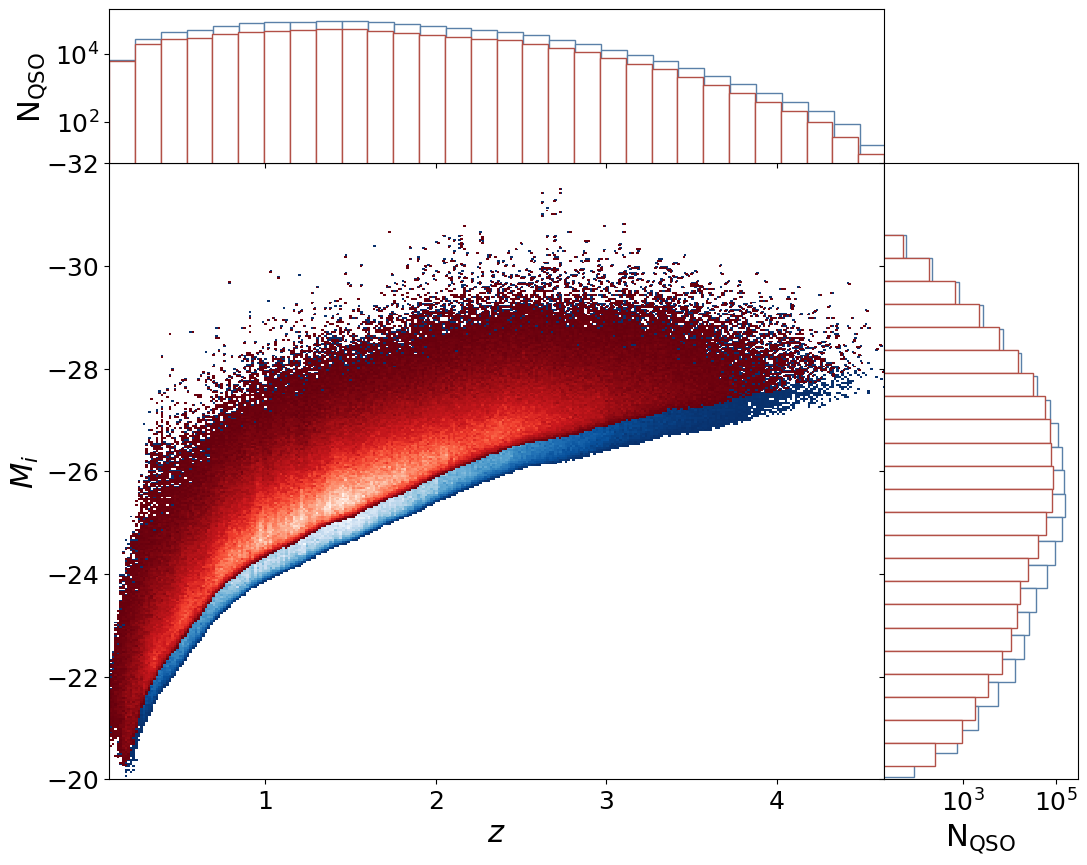

In [17]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
quaia.absolute(tab_datalo, G_lo)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap_blues, bins = 300, 
                                       cmin = 1)
h1, xedges, yedges, image = ax1.hist2d(tab_datalo['redshift_quaia'][mask_datalo], tab_datalo['M_i'][mask_datalo], cmap = cmap_reds, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = blue, bins = 30)
ax2.hist(tab_datalo['redshift_quaia'][mask_datalo], color = 'white', edgecolor = red, bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = blue, orientation = 'horizontal', bins = 25)
ax3.hist(tab_datalo['M_i'][mask_datalo], color = 'white', edgecolor = red, orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in 1 mag L bins

In [22]:
L_bins = [-32.0, -28.0, -27.0, -26.0, -25.0, -24.0, -20.0]
L_array = range(len(L_bins)-1)
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(L_array)))[::-1]
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(L_array)))[::-1]
cmaps = [cmap_red, cmap_blue]
tabs = [tab_datalo[mask_datalo], tab_datahi[mask_datahi]]
G_array = [G_lo, G_hi]
labels = ['${}<M_i\leq{}$'.format(L_bins[i], L_bins[i]+np.diff(L_bins)[i]) for i in range(len(L_bins)-1)]
labels

['$-32.0<M_i\\leq-28.0$',
 '$-28.0<M_i\\leq-27.0$',
 '$-27.0<M_i\\leq-26.0$',
 '$-26.0<M_i\\leq-25.0$',
 '$-25.0<M_i\\leq-24.0$',
 '$-24.0<M_i\\leq-20.0$']

_G20.0_Lmin-32.0Lmax-28.0
_G20.0_Lmin-28.0Lmax-27.0
_G20.0_Lmin-27.0Lmax-26.0
_G20.0_Lmin-26.0Lmax-25.0
_G20.0_Lmin-25.0Lmax-24.0
_G20.0_Lmin-24.0Lmax-20.0
_G20.5_Lmin-32.0Lmax-28.0
_G20.5_Lmin-28.0Lmax-27.0
_G20.5_Lmin-27.0Lmax-26.0
_G20.5_Lmin-26.0Lmax-25.0
_G20.5_Lmin-25.0Lmax-24.0
_G20.5_Lmin-24.0Lmax-20.0


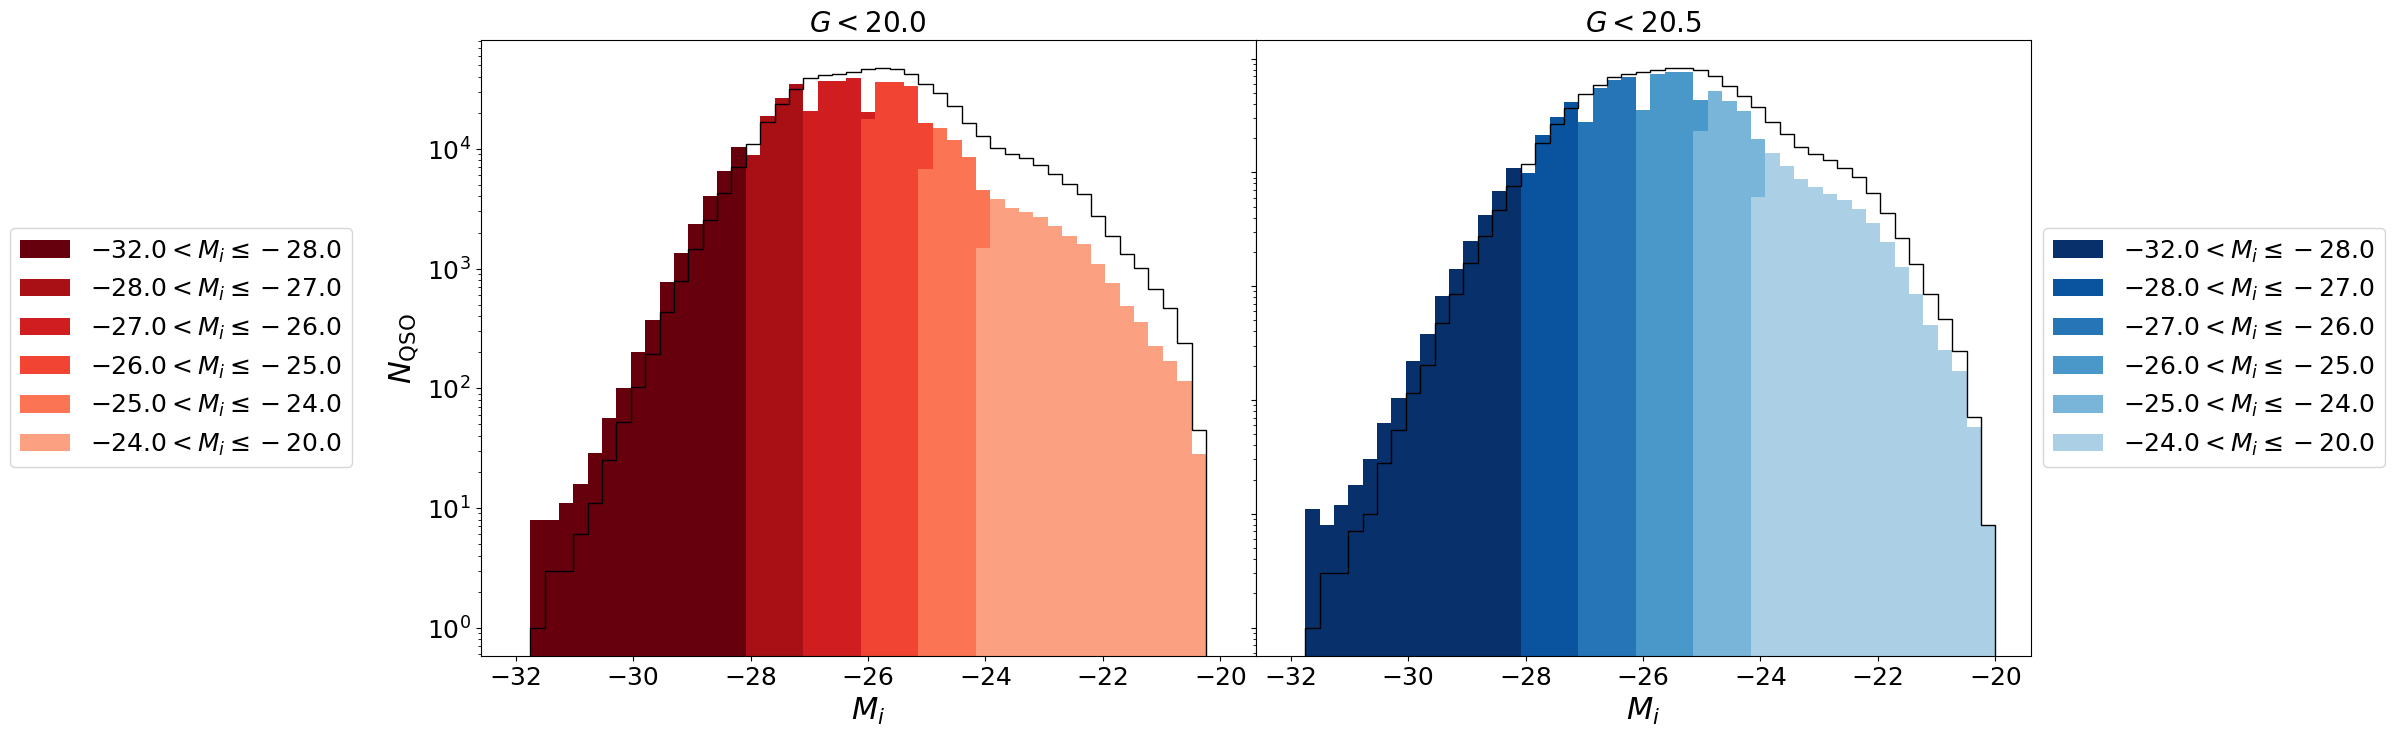

In [26]:
# plot data
bins = np.linspace(-32,-20)

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)
locs = ['center right', 'center left']
x = [-0.15, 1]
for i in range(len(G_array)):

    ax1 = fig.add_subplot(gs[i])
    ax1.hist(tabs[i]['M_i'], bins=bins, histtype = 'step', color='black')

    for j in range(len(labels)):
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _ = quaia.make_bins(G_array[i], j, True, 'L', bins = L_bins,
                                                                                        tab_gcat_type = 'data', method = 'minmax', fac_rand = 25)
        ax1.hist(tab_datahi_mask_zbin0['M_i'], label = labels[j], bins = bins, color = cmaps[i][j])

    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel('$M_i$')
    ax1.set_yscale('log')
    ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5))
    if i>0:
        ax1.set_yticklabels([])
    else:
        ax1.set_ylabel('$N_\mathrm{QSO}$')

plt.show()

## $\xi(s)$

In [27]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# # Create the bins array
# rmin = 0.1 # 0.1 # start higher
# rmax = 155.0 # 20.0 #50.0
# nbins = 20 #90 #20
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [28]:
# plot data
# bins = np.linspace(-32,-20)
cf = {G_lo: [], G_hi: []}

for i in range(len(G_array)):

    for j in range(len(labels)):
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _ = quaia.make_bins(G_array[i], j, True, 'L', bins = L_bins,
                                                                                        tab_gcat_type = 'data', method = 'minmax', fac_rand = 25)
        cf[G_array[i]].append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins))

_G20.0_Lmin-32.0Lmax-28.0


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_Lmin-28.0Lmax-27.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_Lmin-27.0Lmax-26.0


...

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_Lmin-25.0Lmax-24.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_Lmin-24.0Lmax-20.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


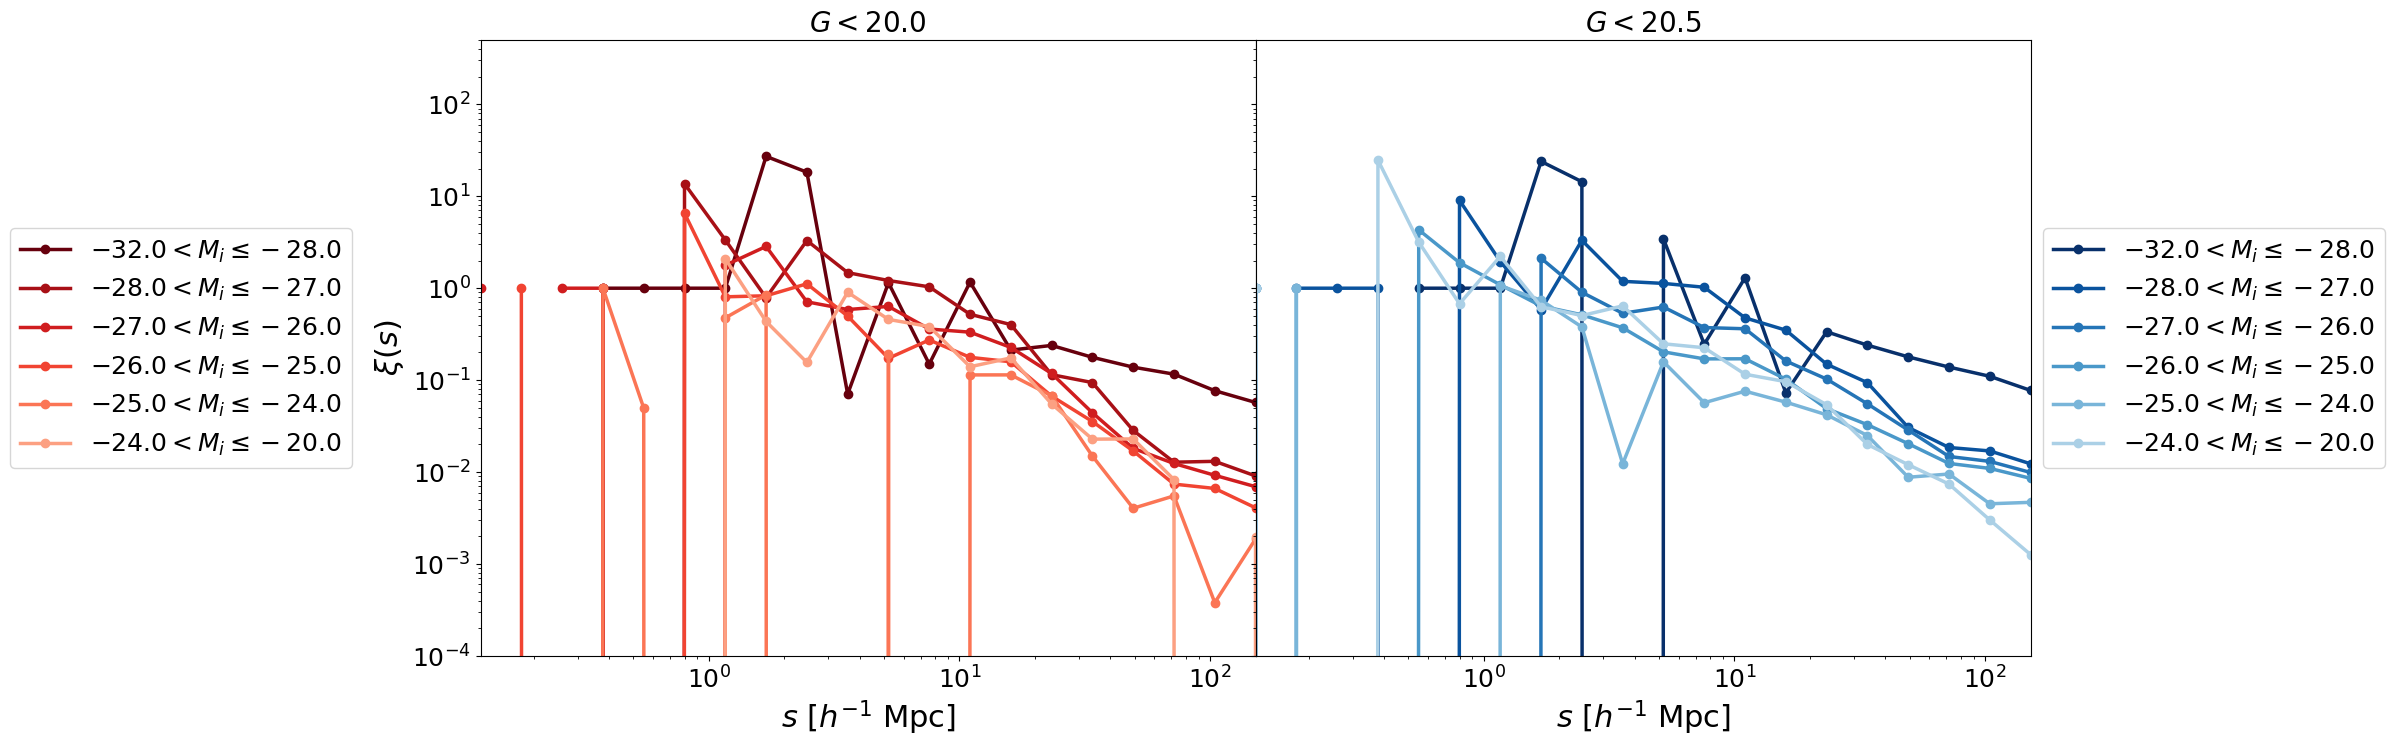

In [30]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(quaia.recenter(rbins), cf[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', color = cmaps[i][Lbin])
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-4, 5e2)
    ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5))
    if i==0:
        ax1.set_ylabel(r"$\xi(s)$")
    else:
        ax1.set_yticklabels([])

plt.show()

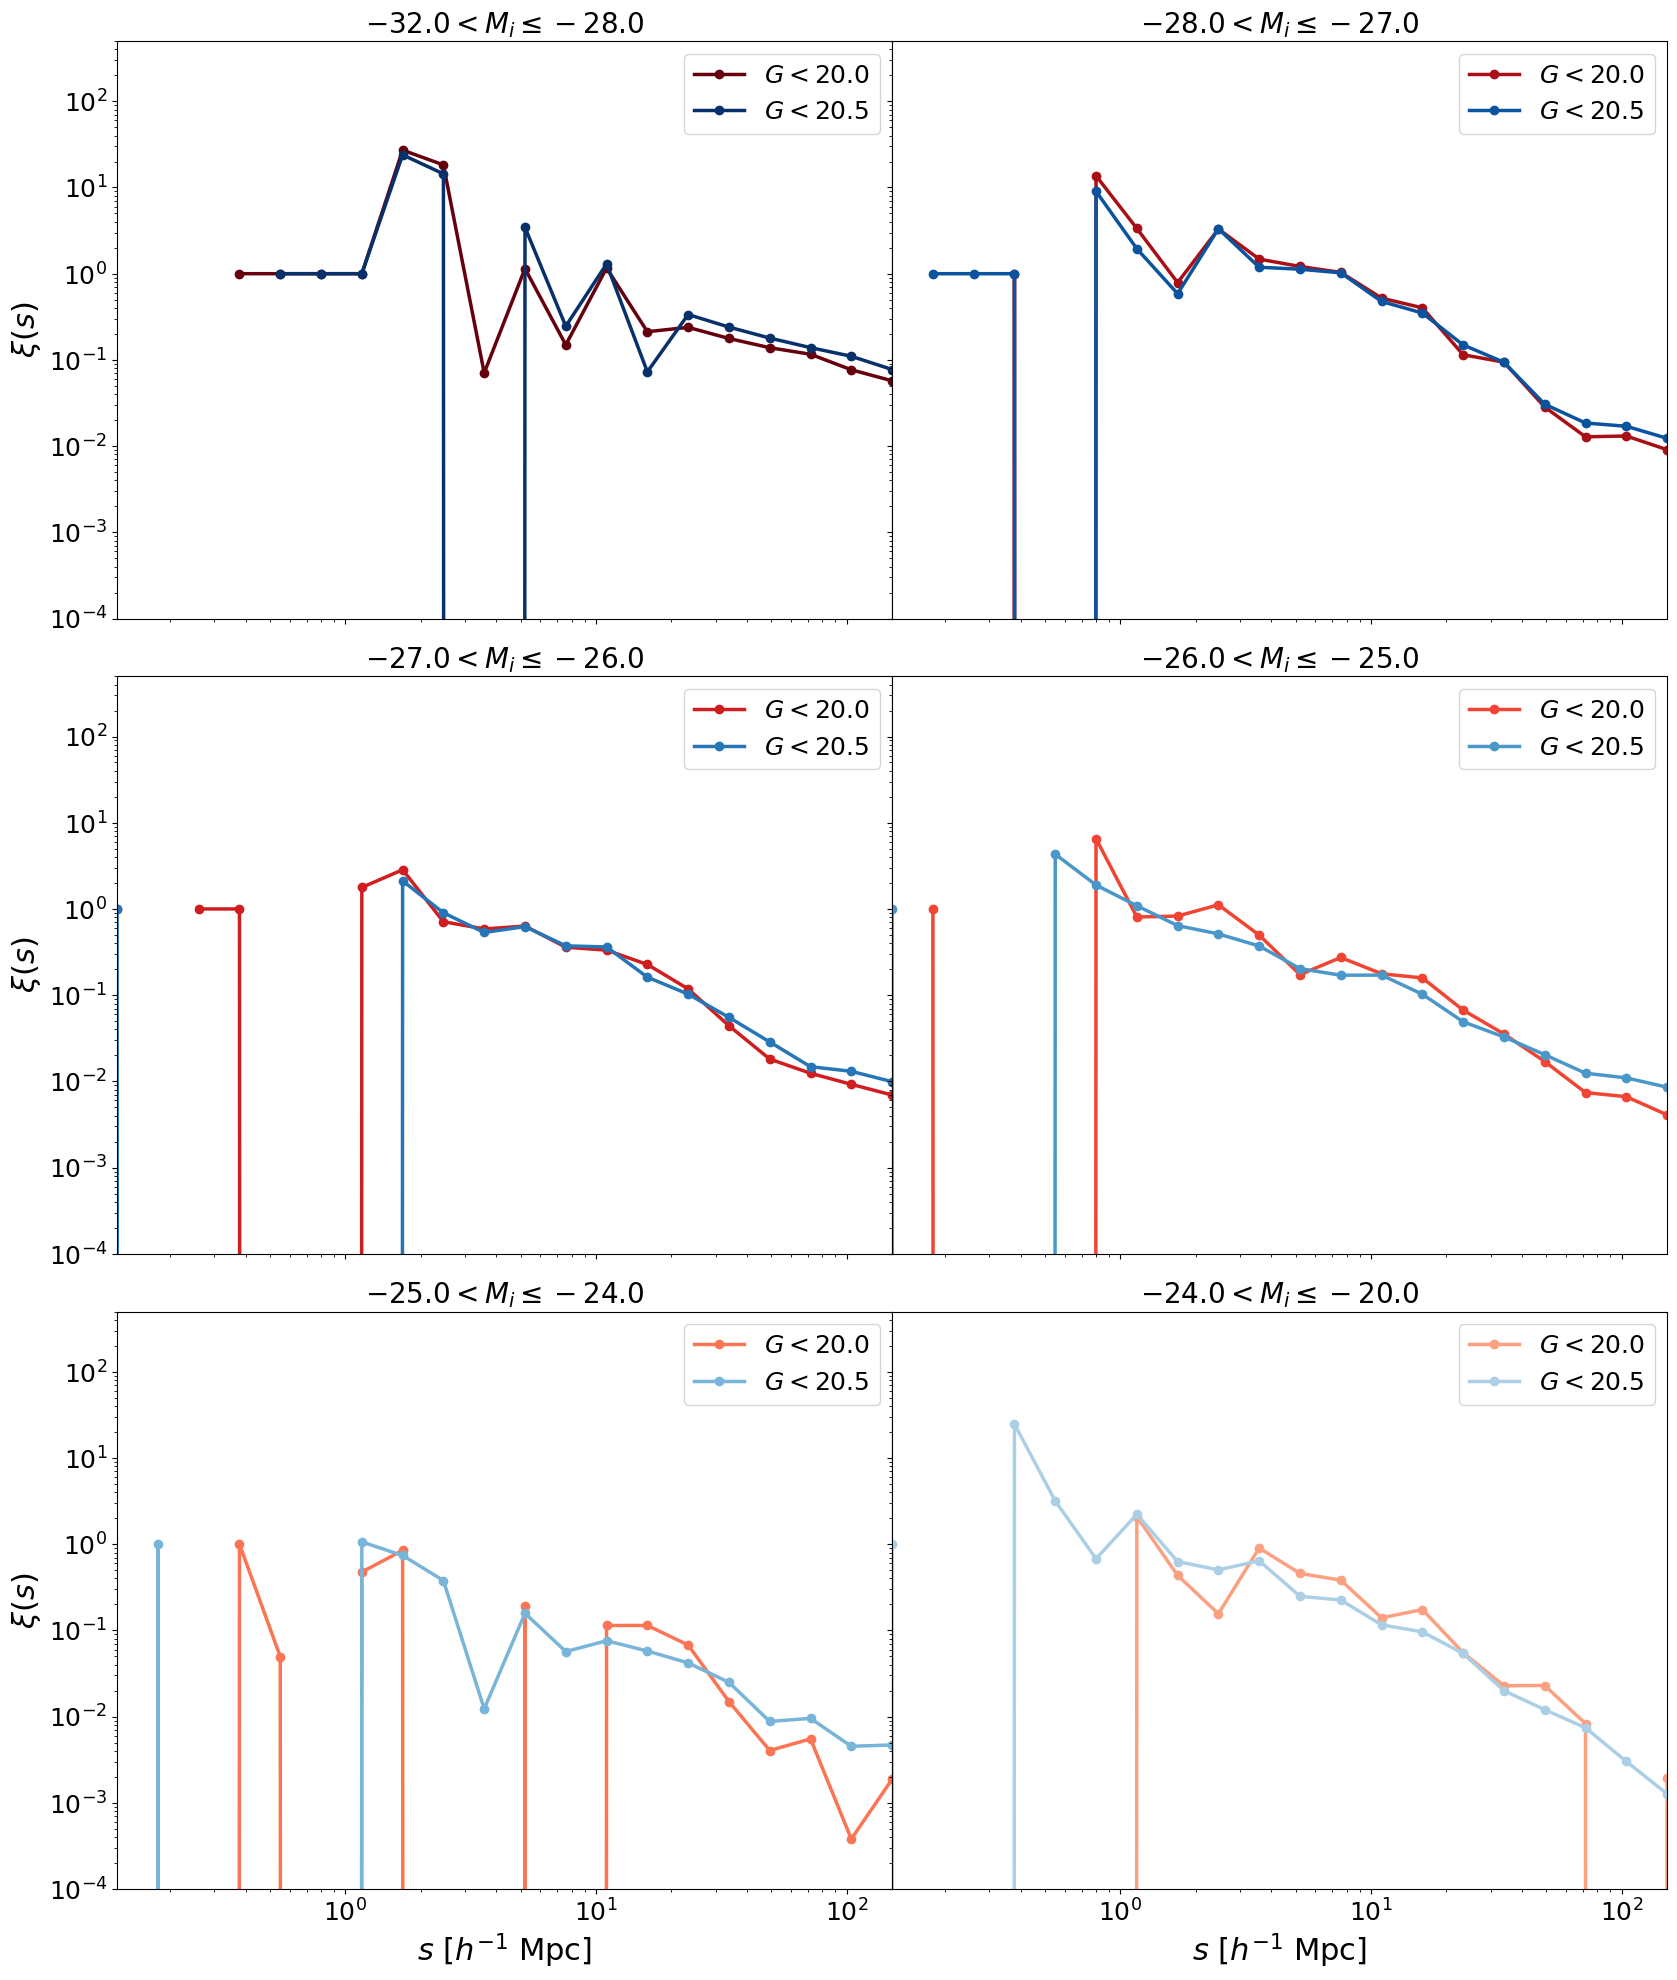

In [32]:
# plot!
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(3, 2, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):
        
        ax1.plot(quaia.recenter(rbins), cf[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-4, 5e2)
    ax1.legend()
    if Lbin > 3:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    else: 
        ax1.set_xticklabels([])
    if Lbin%2==0:
        ax1.set_ylabel(r"$\xi(s)$")
    else:
        ax1.set_yticklabels([])

plt.show()

## $w_p(r_p)$

In [33]:
# Create the bins array
rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 210 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [34]:
pimax = 80 # 40 # 5000.0 # 40.0

In [35]:
# plot data
wp, rpavg = {20.0: [], 20.5: []}, {20.0: [], 20.5: []}
for G in G_array:

    for Lbin in L_array:
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _ = quaia.make_bins(G, Lbin, True, 'L', bins = L_bins, fac_rand = 25, 
                                                                                        method = 'minmax', tab_gcat_type = 'data')

        wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins, 
                                                           nbins = nbins, pimax = pimax)
        wp[G].append(wp_datahi_zbin0)
        rpavg[G].append(rpavg_datahi_zbin0)

_G20.0_Lmin-32.0Lmax-28.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:653: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])


_G20.0_Lmin-28.0Lmax-27.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_Lmin-27.0Lmax-26.0


...

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_Lmin-25.0Lmax-24.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_Lmin-24.0Lmax-20.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


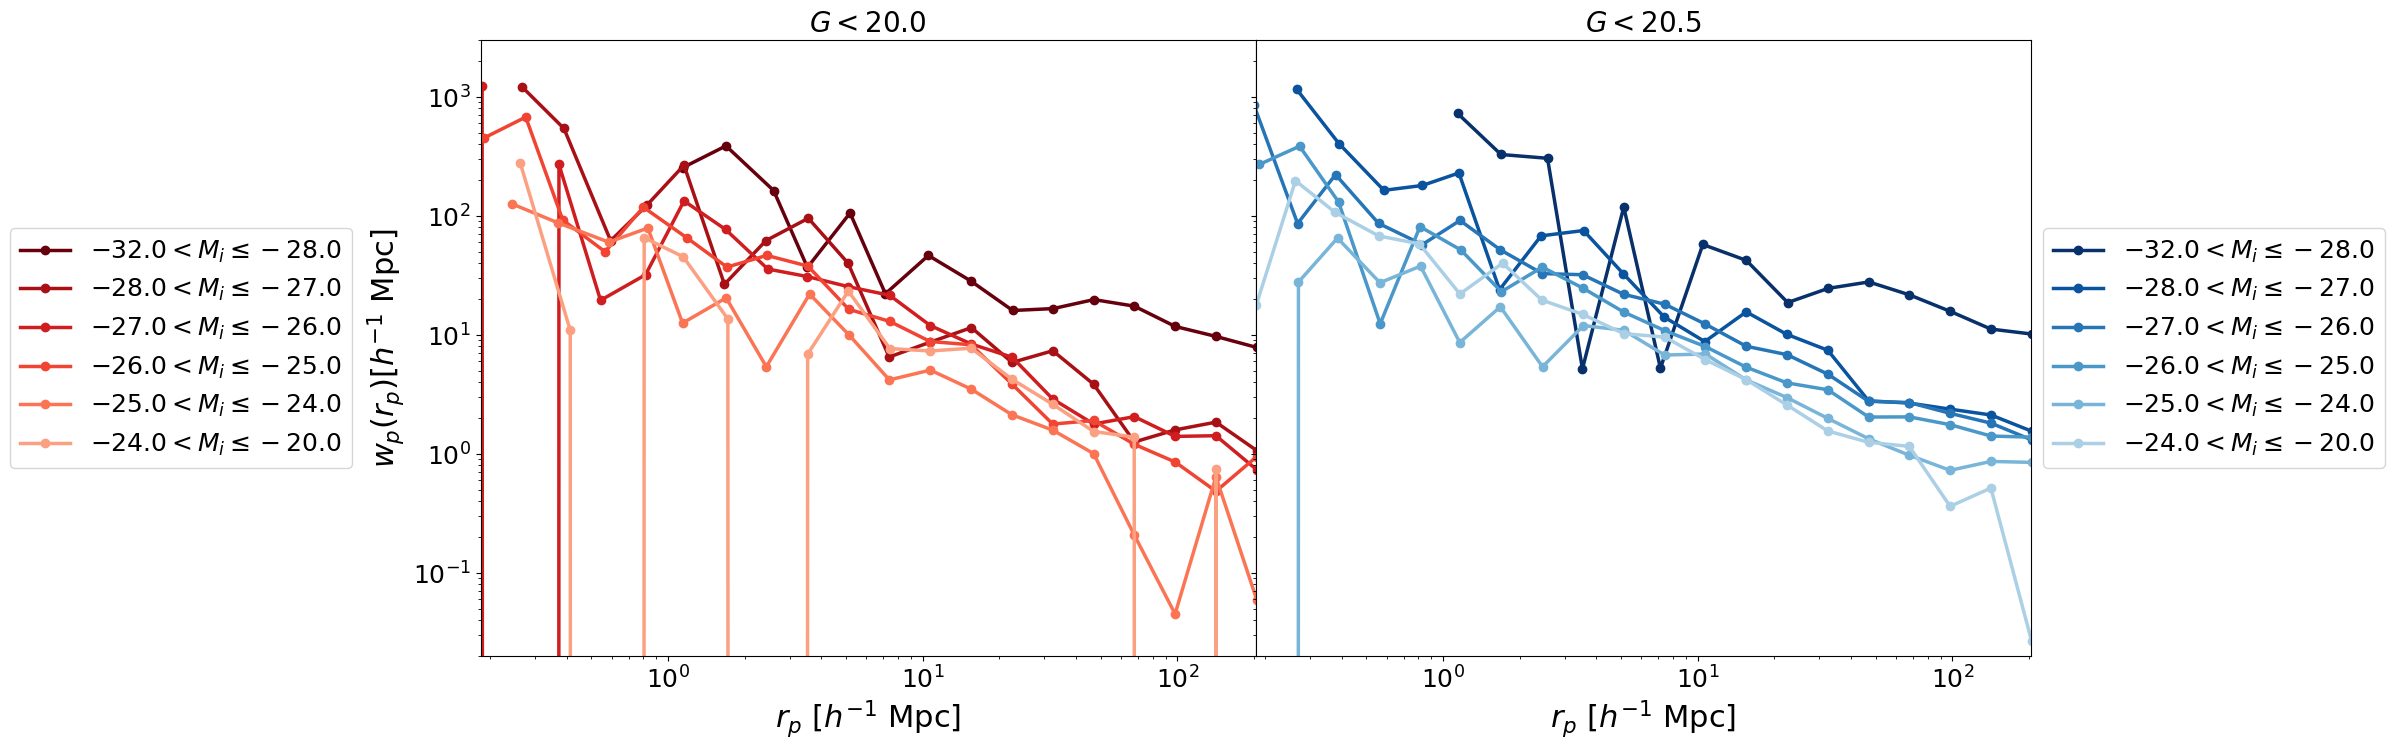

In [36]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(rpavg[G_array[i]][Lbin], wp[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', color = cmaps[i][Lbin])
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(2e-2, 3e3)
    ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5))
    
    if i==0:
        ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])

plt.show()

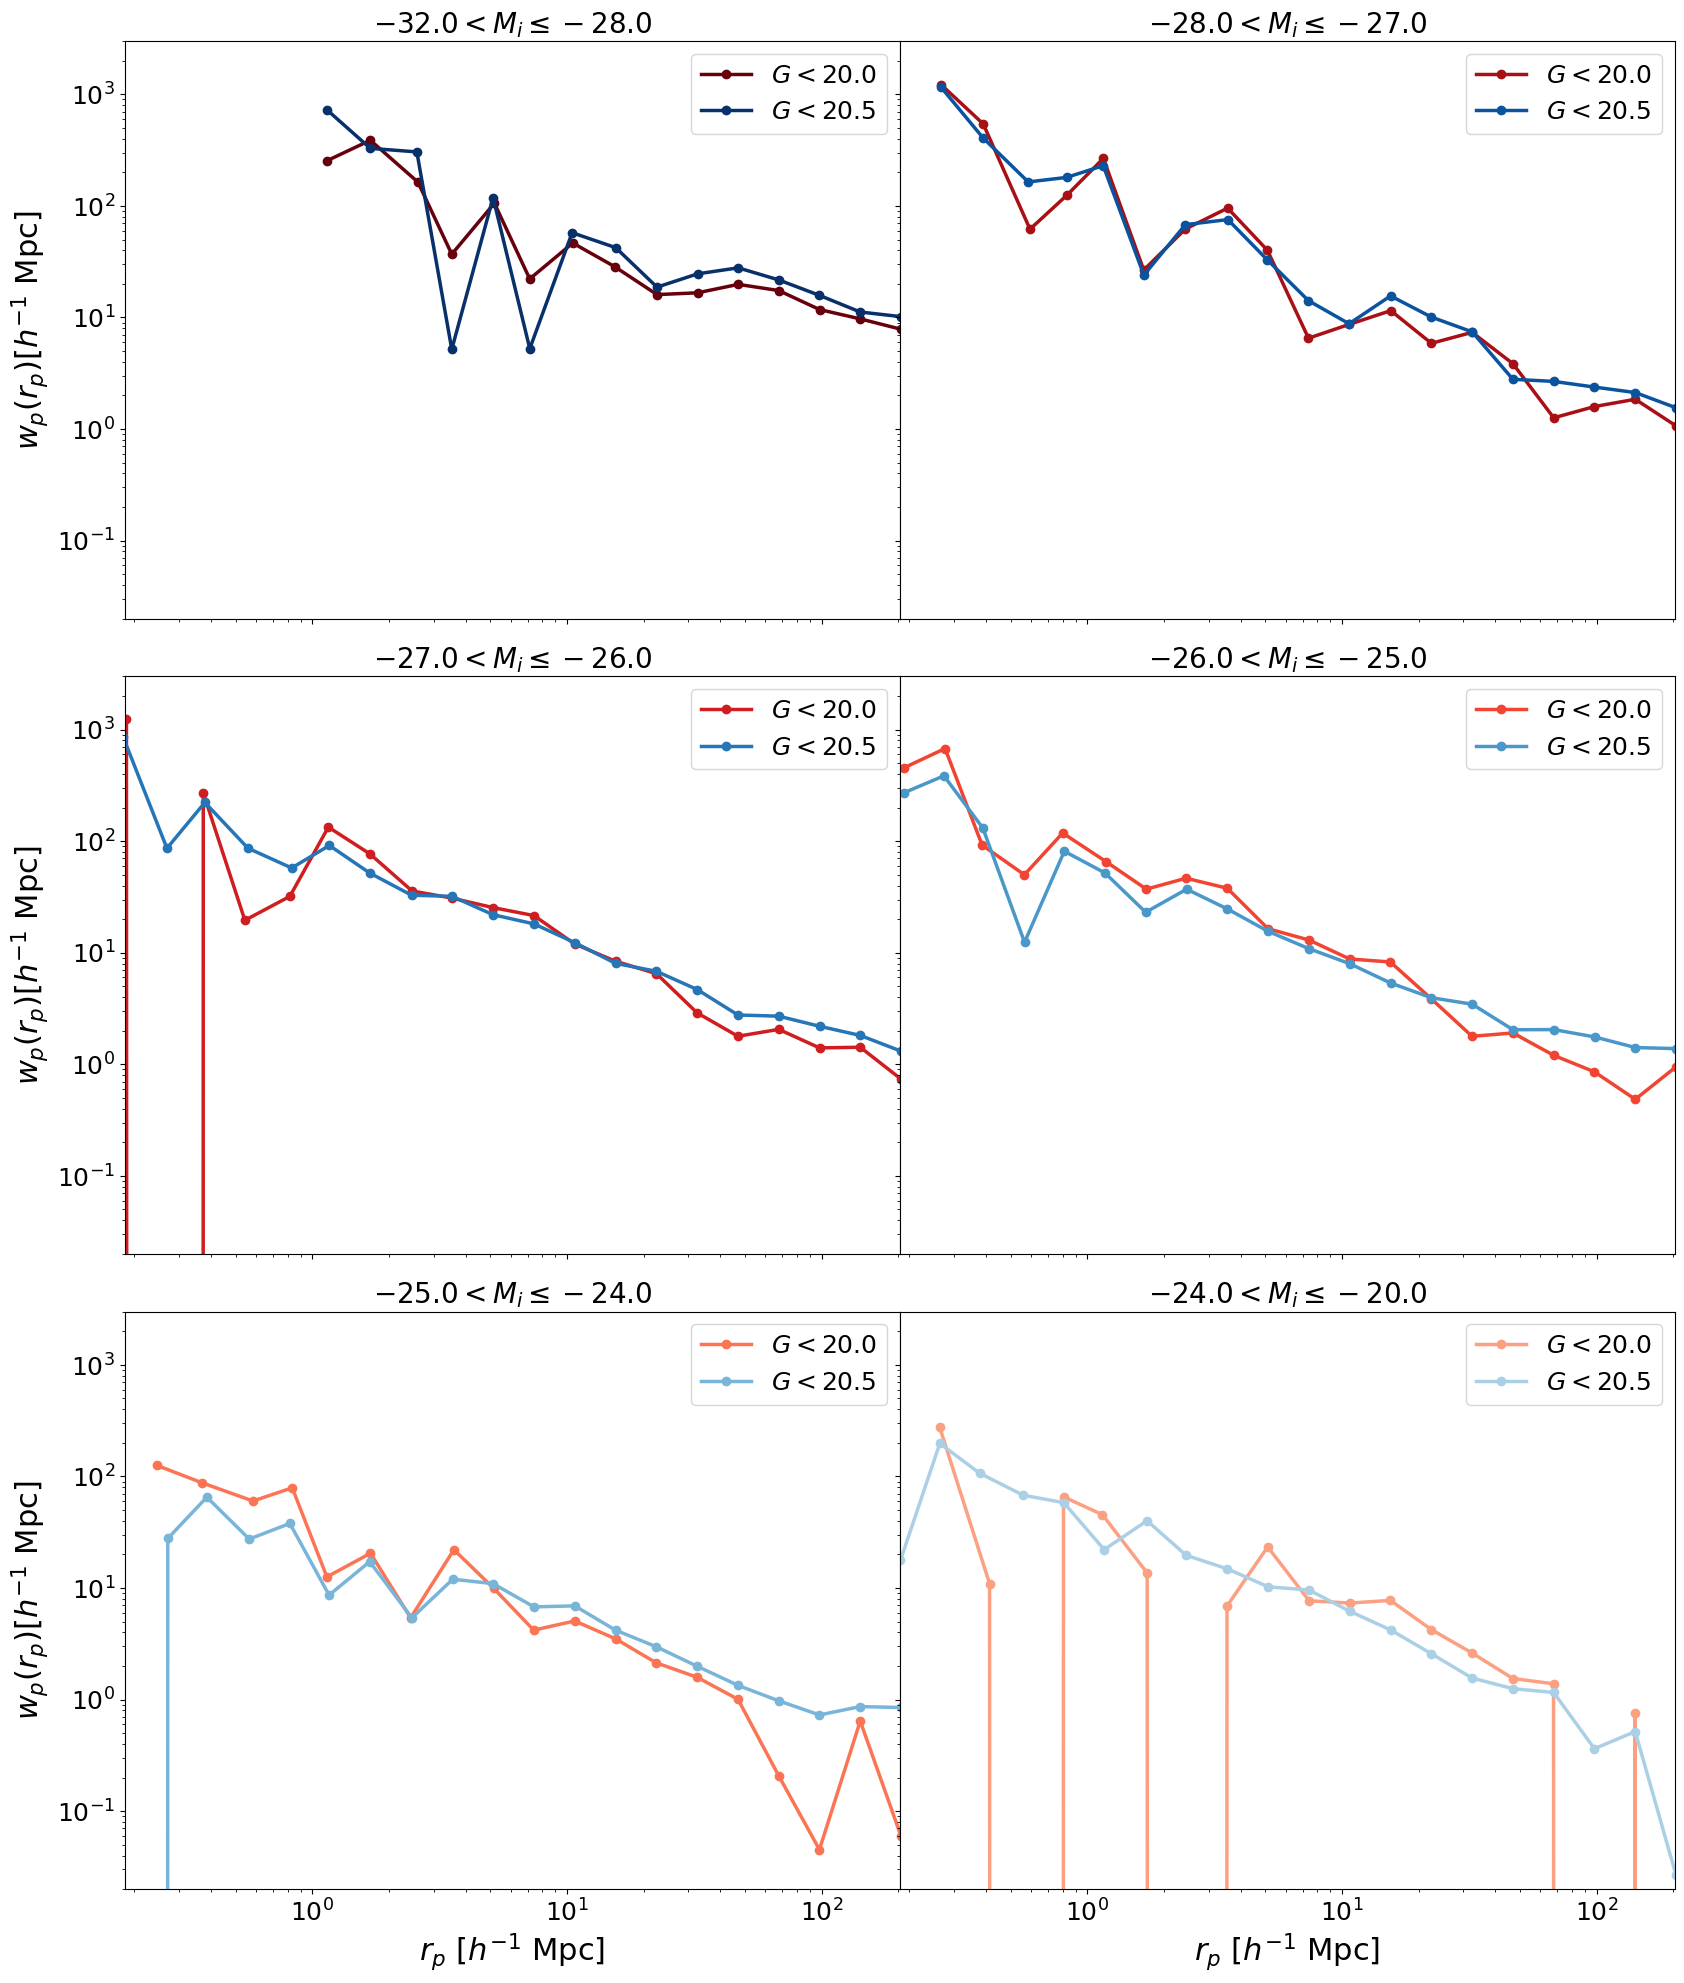

In [37]:
# plot!
row = 3
col = 2
fig = plt.figure(figsize = (col*10, row*8))
gs = gridspec.GridSpec(row, col, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(rpavg[G][Lbin], wp[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(2e-2, 3e3)
    ax1.legend()
    if Lbin>(np.max(L_array)-col):
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])
    if Lbin%col==0:
        ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])

plt.show()

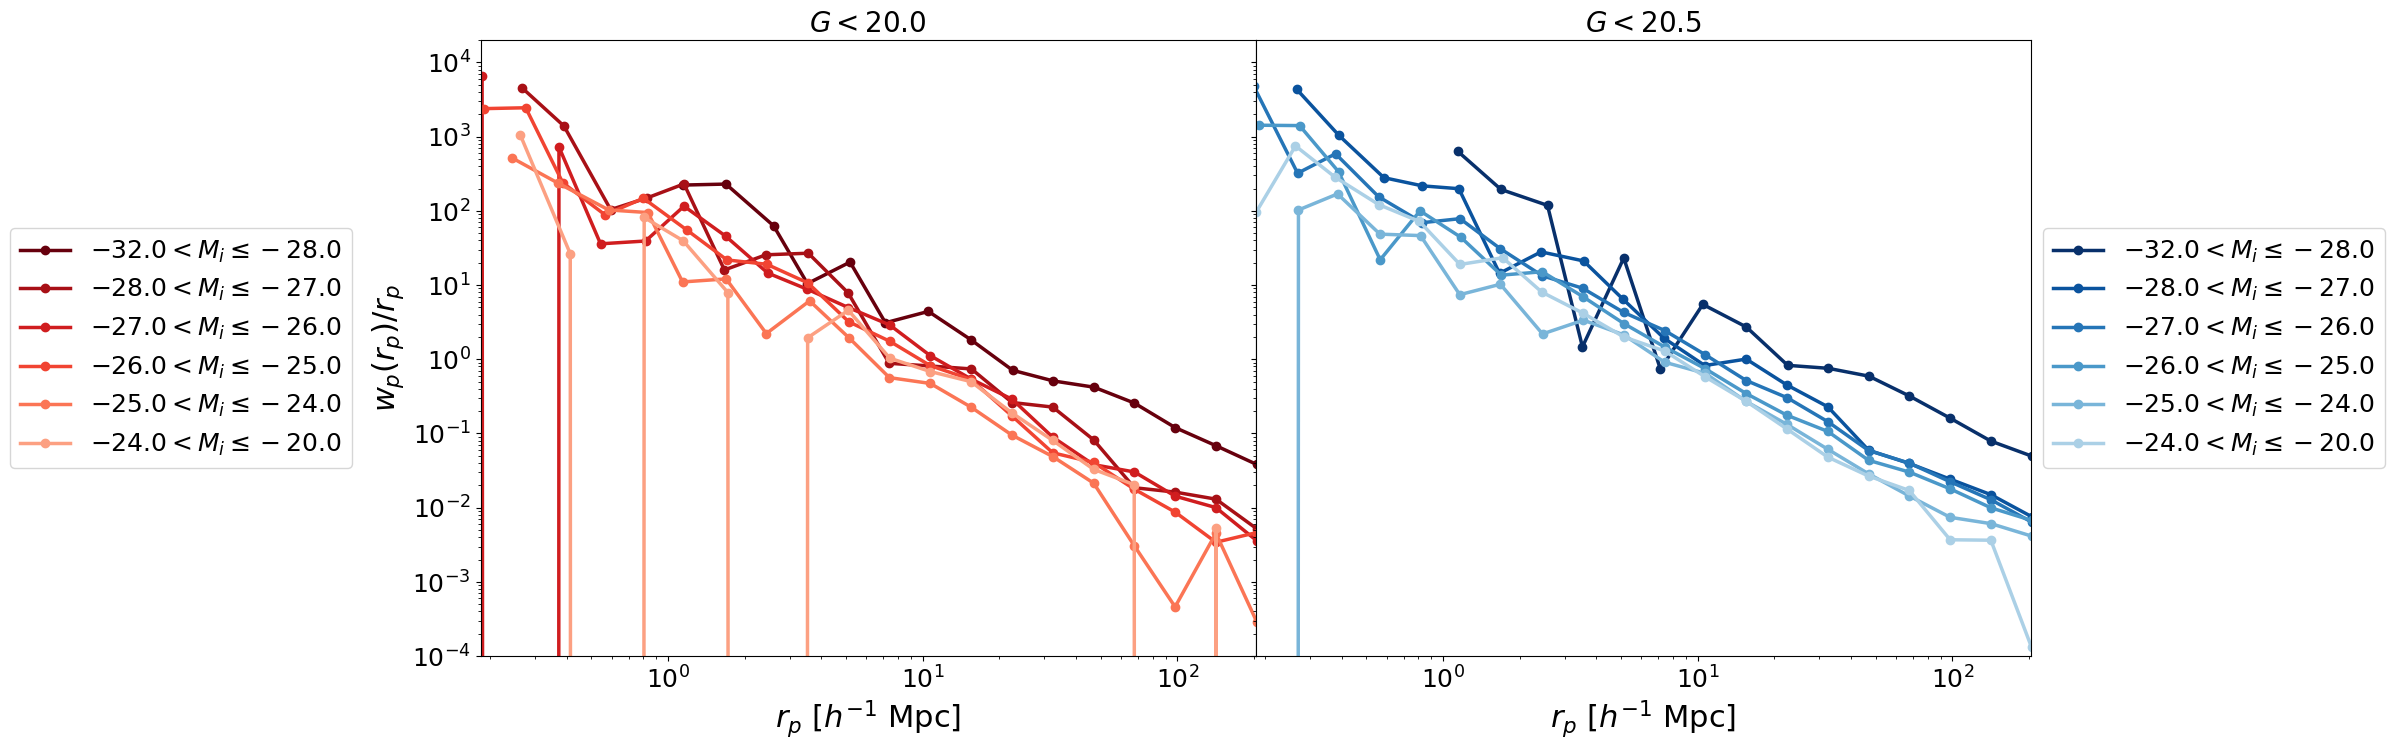

In [38]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(rpavg[G_array[i]][Lbin], wp[G_array[i]][Lbin]/rpavg[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][Lbin])
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-4, 2e4)
    ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5))
    if i==0:
        ax1.set_ylabel(r"$w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])

plt.show()

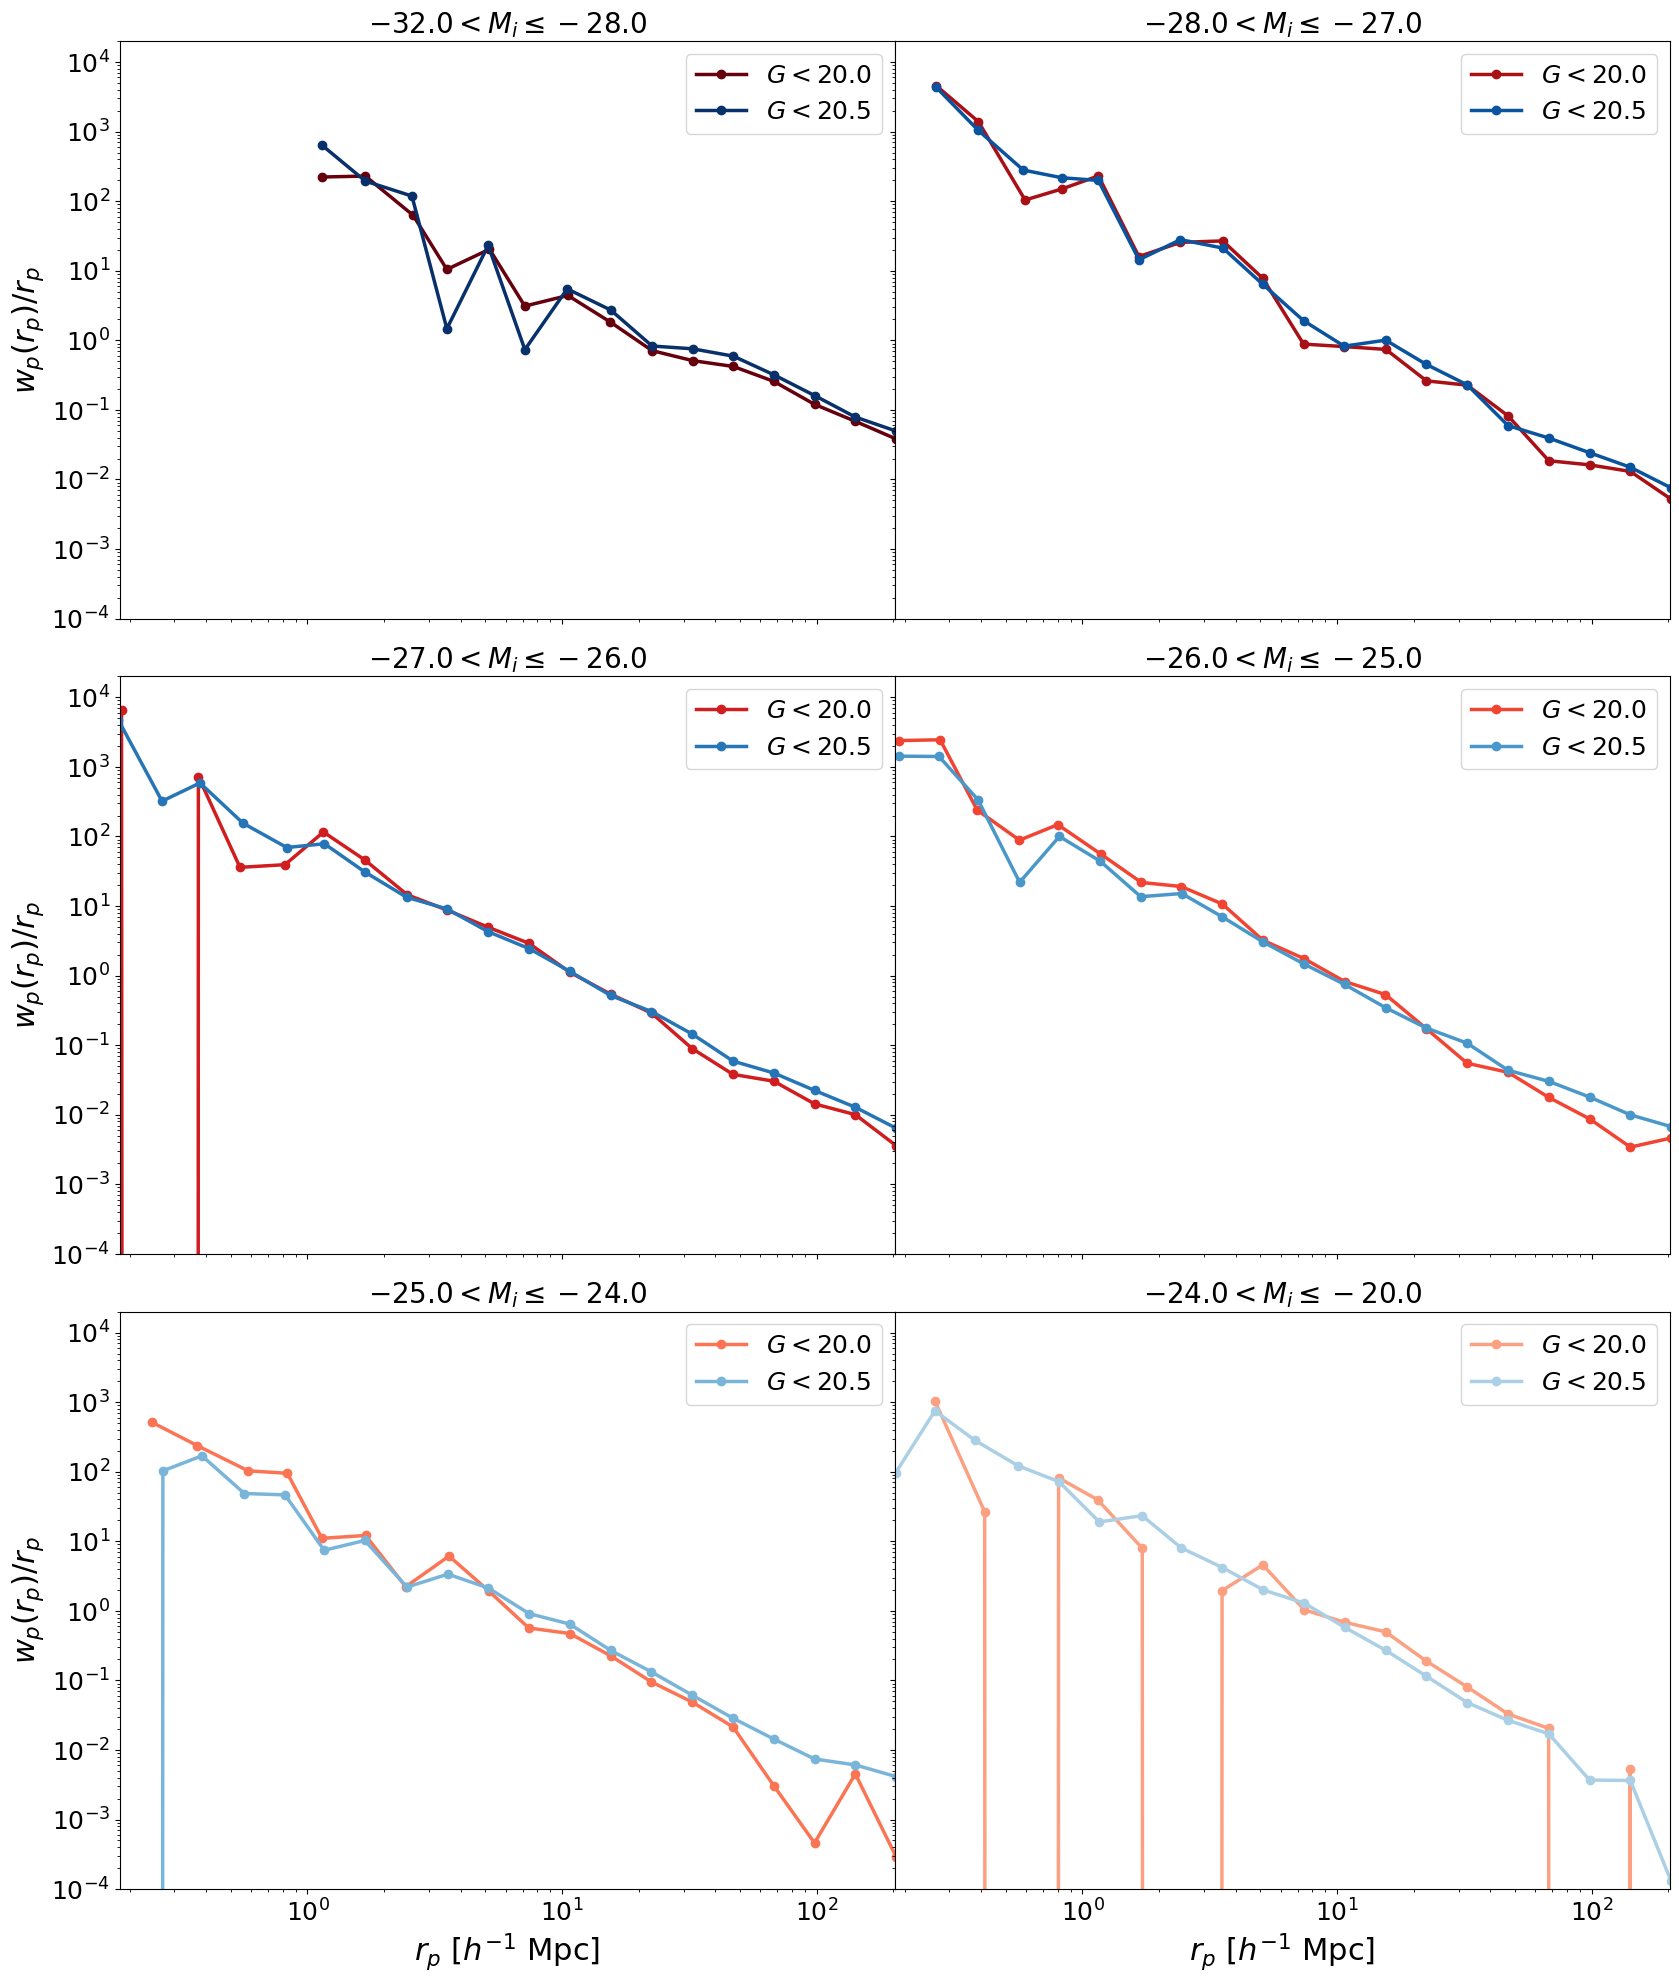

In [39]:
# plot!
fig = plt.figure(figsize = (col*10, row*8))
gs = gridspec.GridSpec(row, col, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(rpavg[G][Lbin], wp[G][Lbin]/rpavg[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-4, 2e4)
    ax1.legend()
    if Lbin%col==0:
        ax1.set_ylabel(r"$w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])
    if Lbin>(np.max(L_array)-col):
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])

plt.show()

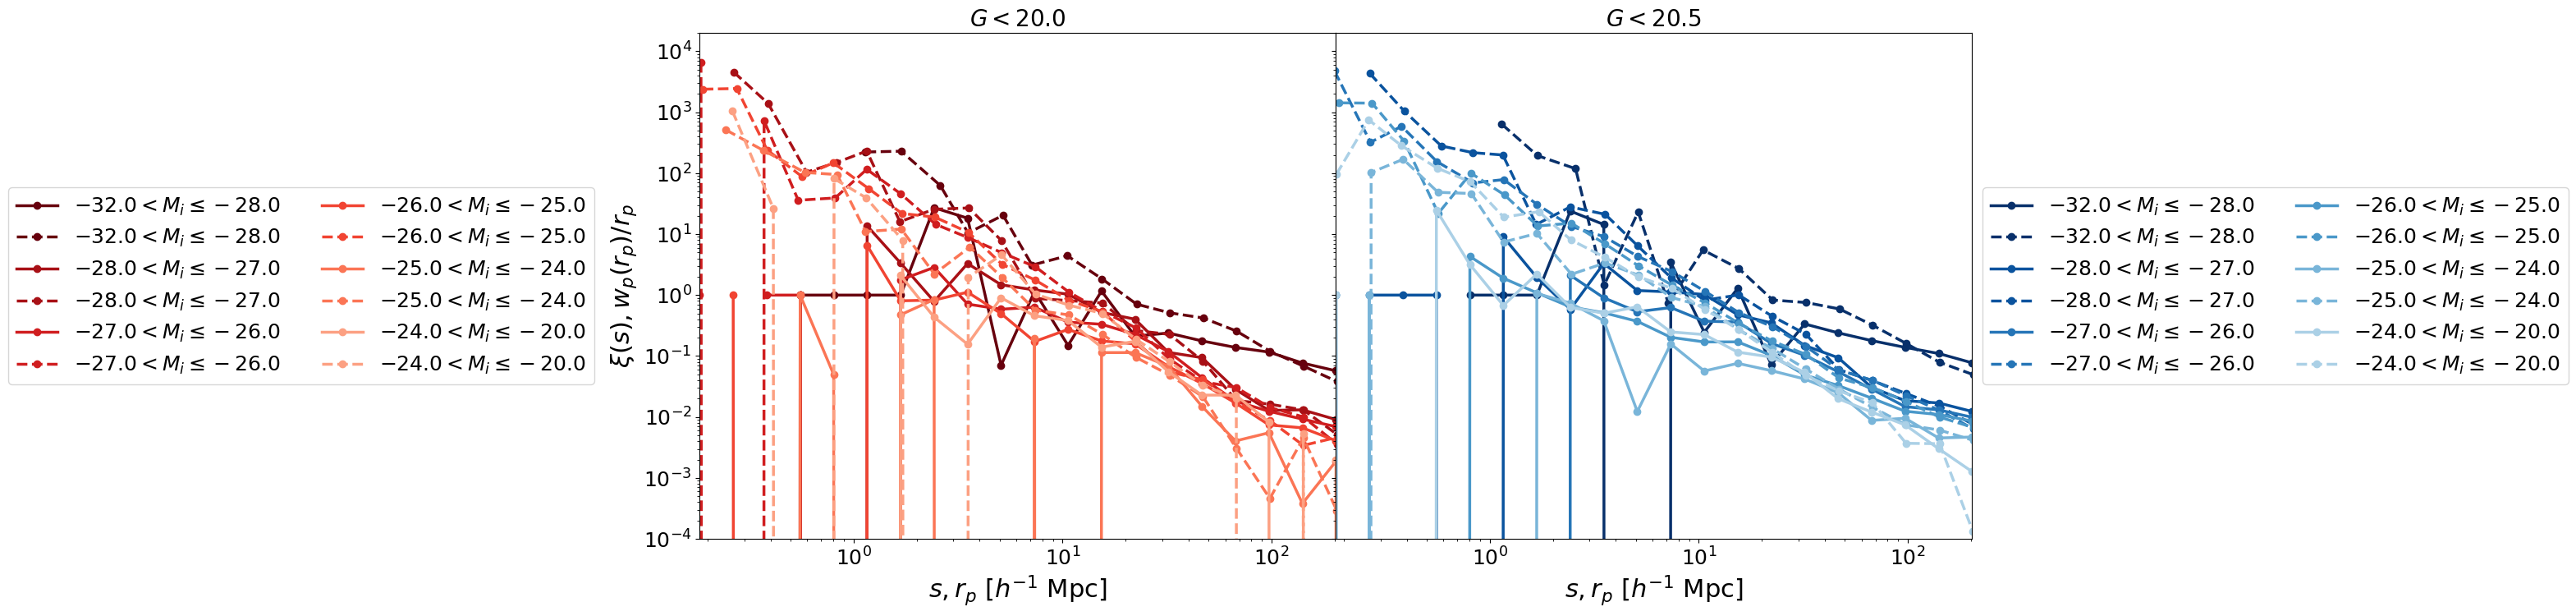

In [48]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(quaia.recenter(rbins), cf[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', color = cmaps[i][Lbin])
        ax1.plot(rpavg[G_array[i]][Lbin], wp[G_array[i]][Lbin]/rpavg[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][Lbin], linestyle = '--')
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-4, 2e4)
    ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5), ncol = 2)
    if i==0:
        ax1.set_ylabel(r"$\xi(s), w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])

plt.show()

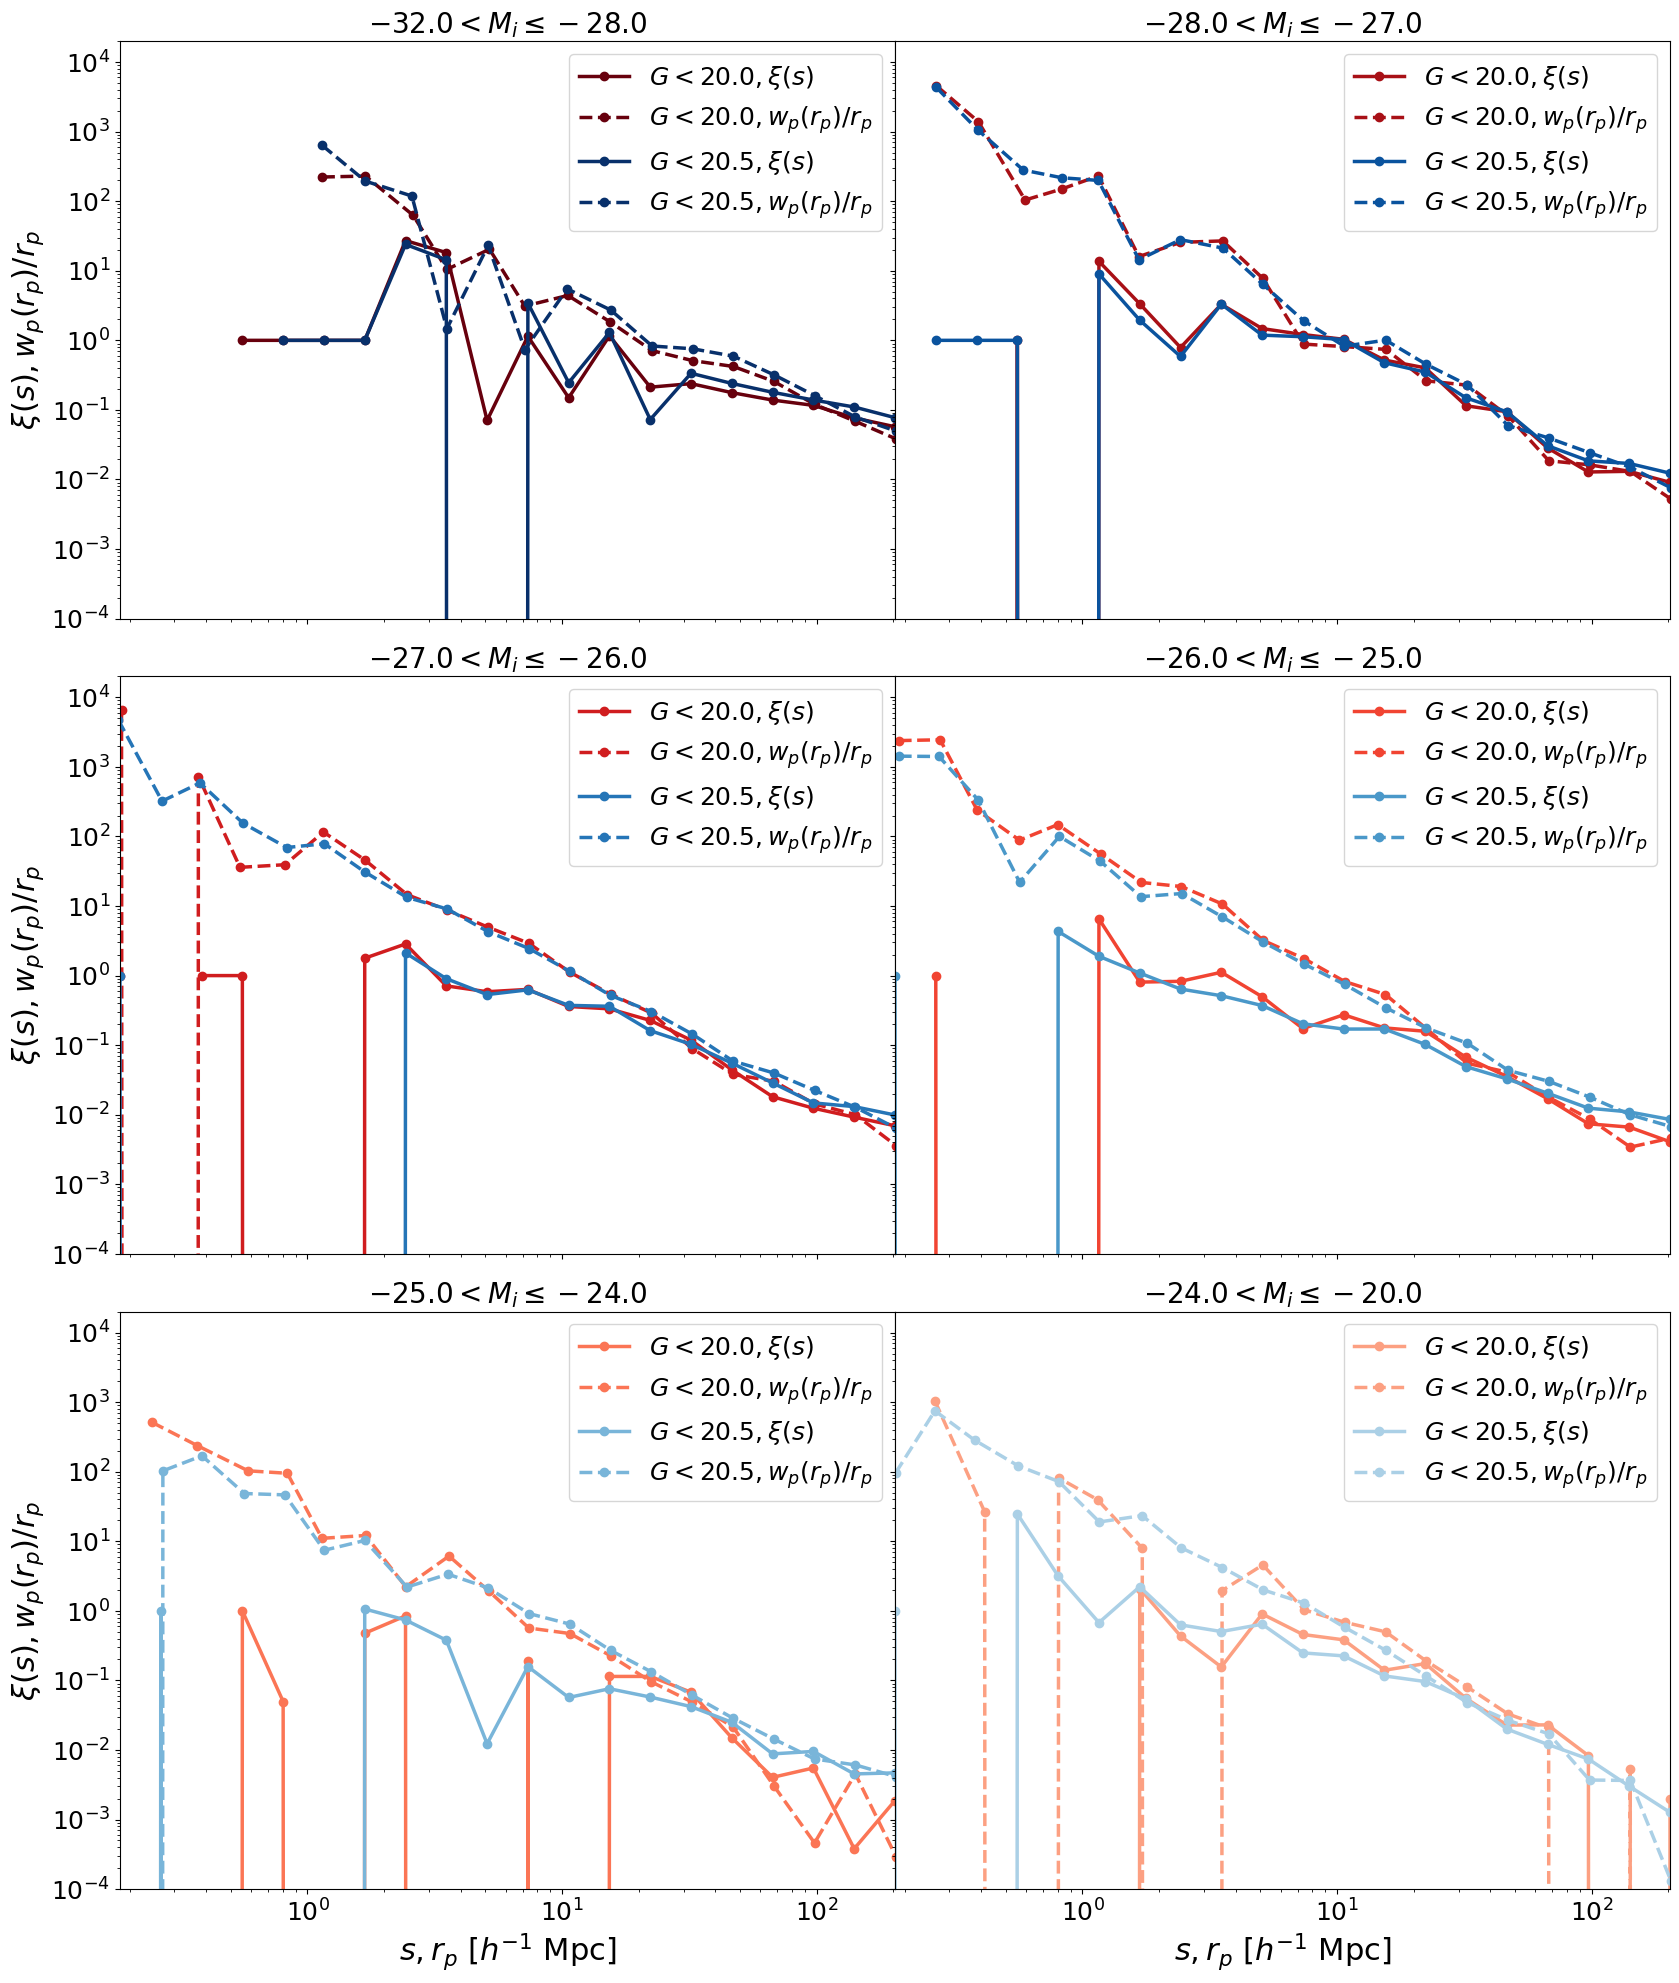

In [53]:
# plot!
fig = plt.figure(figsize = (col*10, row*8))
gs = gridspec.GridSpec(row, col, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(quaia.recenter(rbins), cf[G][Lbin], label = '$G<{}, \\xi(s)$'.format(G), linewidth = 2.5, marker = 'o', color = cmap[Lbin])
        ax1.plot(rpavg[G][Lbin], wp[G][Lbin]/rpavg[G][Lbin], label = '$G<{}, w_p(r_p)/r_p$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin], linestyle = '--')
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-4, 2e4)
    ax1.legend()
    if Lbin%col==0:
        ax1.set_ylabel(r"$\xi(s), w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])
    if Lbin>(np.max(L_array)-col):
        ax1.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])

plt.show()

## $w(\theta)$

In [41]:
# Create the bins array
# thetabins = np.logspace(np.log10(0.1), np.log10(10), 15) 
thetabins = np.logspace(np.log10(0.1), np.log10(35), 15) #(np.log10(0.15), np.log10(35), 15)

In [42]:
# plot data
wtheta = {G_lo: [], G_hi: []}
for G in G_array:

    for Lbin in L_array:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, _, _, _ = quaia.make_bins(G, Lbin, True, 'L', bins = L_bins, fac_rand = 25, method = 'minmax',
                                                                                tab_gcat_type = 'data', z = False)

        wtheta_datahi_zbin0 = quaia.w_theta(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, nthreads = nthreads, thetabins = thetabins)
        wtheta[G].append(wtheta_datahi_zbin0)

_G20.0_Lmin-32.0Lmax-28.0
DD: 0.069102
DR: 2.2271900000000002
RR: 21.697352
_G20.0_Lmin-28.0Lmax-27.0
DD: 0.536747
DR: 23.843697
RR: 257.243214
_G20.0_Lmin-27.0Lmax-26.0
DD: 1.538766
DR: 54.091811
RR: 608.955302
_G20.0_Lmin-26.0Lmax-25.0
DD: 1.334532
DR: 46.539648
RR: 567.065374
_G20.0_Lmin-25.0Lmax-24.0
DD: 0.237032
DR: 8.768547
RR: 79.410515
_G20.0_Lmin-24.0Lmax-20.0
DD: 0.089178
DR: 3.242544
RR: 34.687767
_G20.5_Lmin-32.0Lmax-28.0
DD: 0.093689
DR: 3.354783
RR: 39.960944
_G20.5_Lmin-28.0Lmax-27.0
DD: 1.194201
DR: 35.266936
RR: 341.205857
_G20.5_Lmin-27.0Lmax-26.0
DD: 3.482092
DR: 138.35995
RR: 1641.38458
_G20.5_Lmin-26.0Lmax-25.0
DD: 4.6675889999999995
DR: 242.406122
RR: 2702.222795
_G20.5_Lmin-25.0Lmax-24.0
DD: 0.989382
DR: 43.097382
RR: 498.413924
_G20.5_Lmin-24.0Lmax-20.0
DD: 0.281178
DR: 10.162707
RR: 116.847303


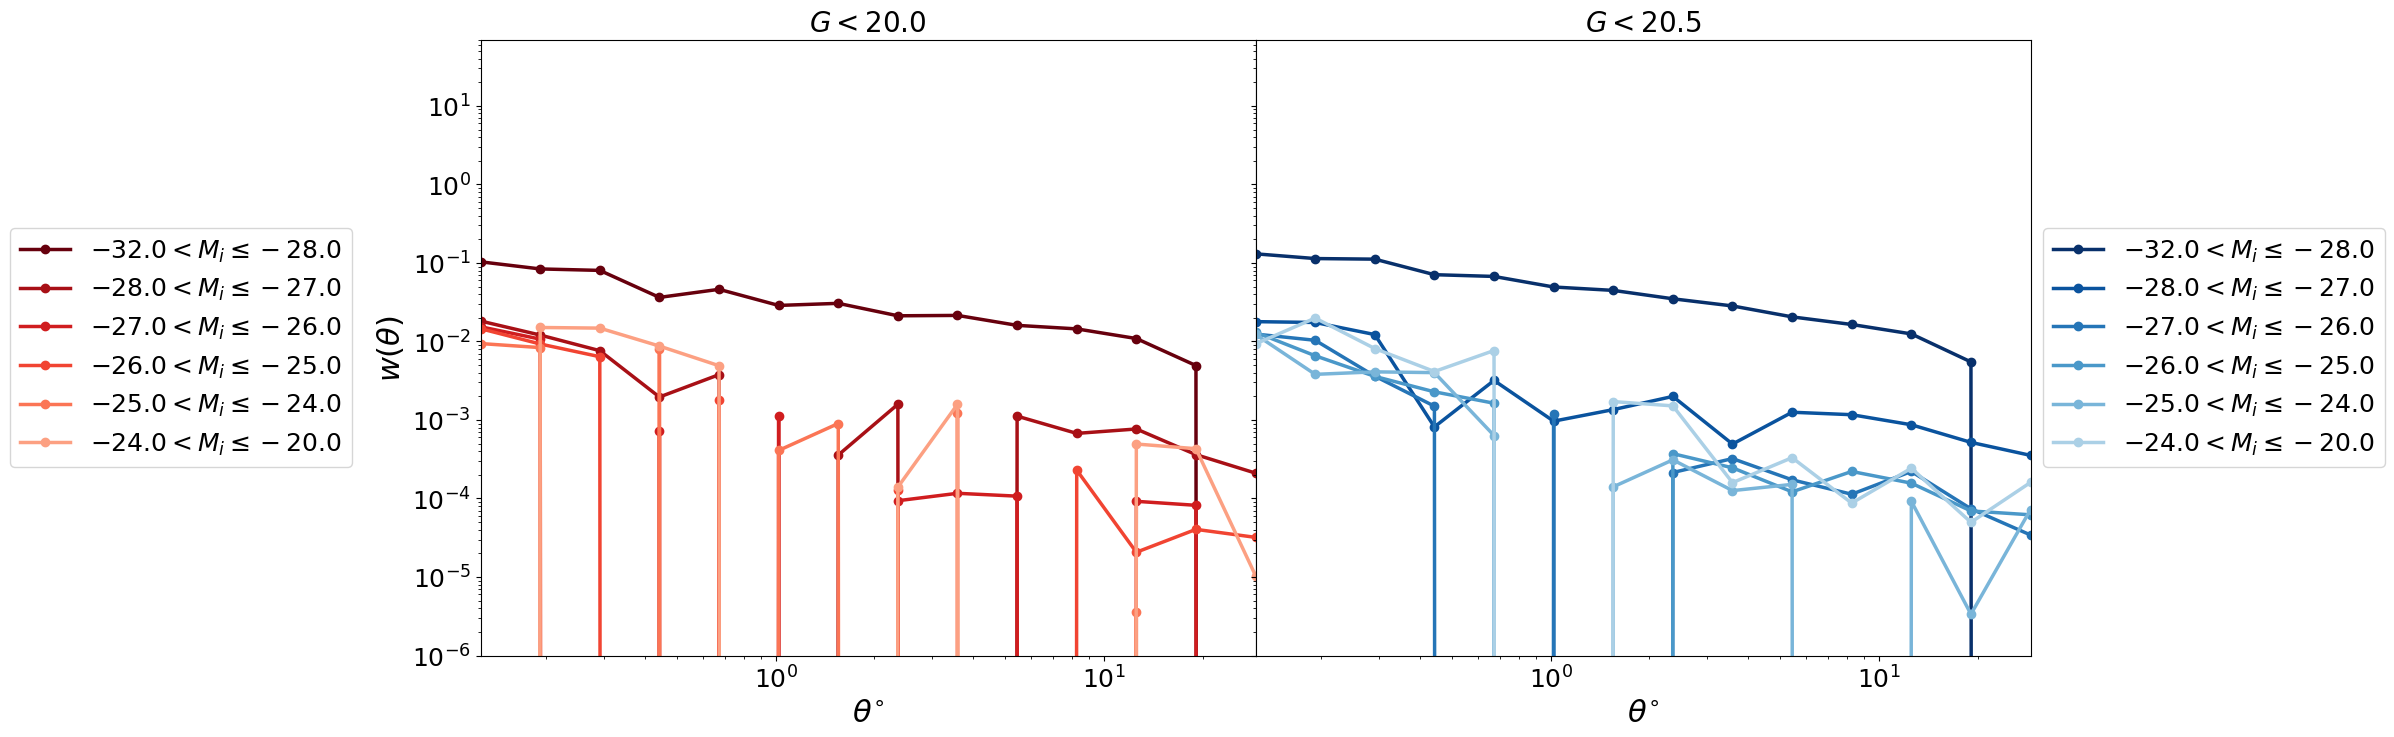

In [43]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][Lbin])
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$\theta^{\circ}$')
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
    ax1.set_ylim(1e-6, 7e1)
    ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5))
    if i==0:
        ax1.set_ylabel(r"$w(\theta)$")
    else:
        ax1.set_yticklabels([])

plt.show()

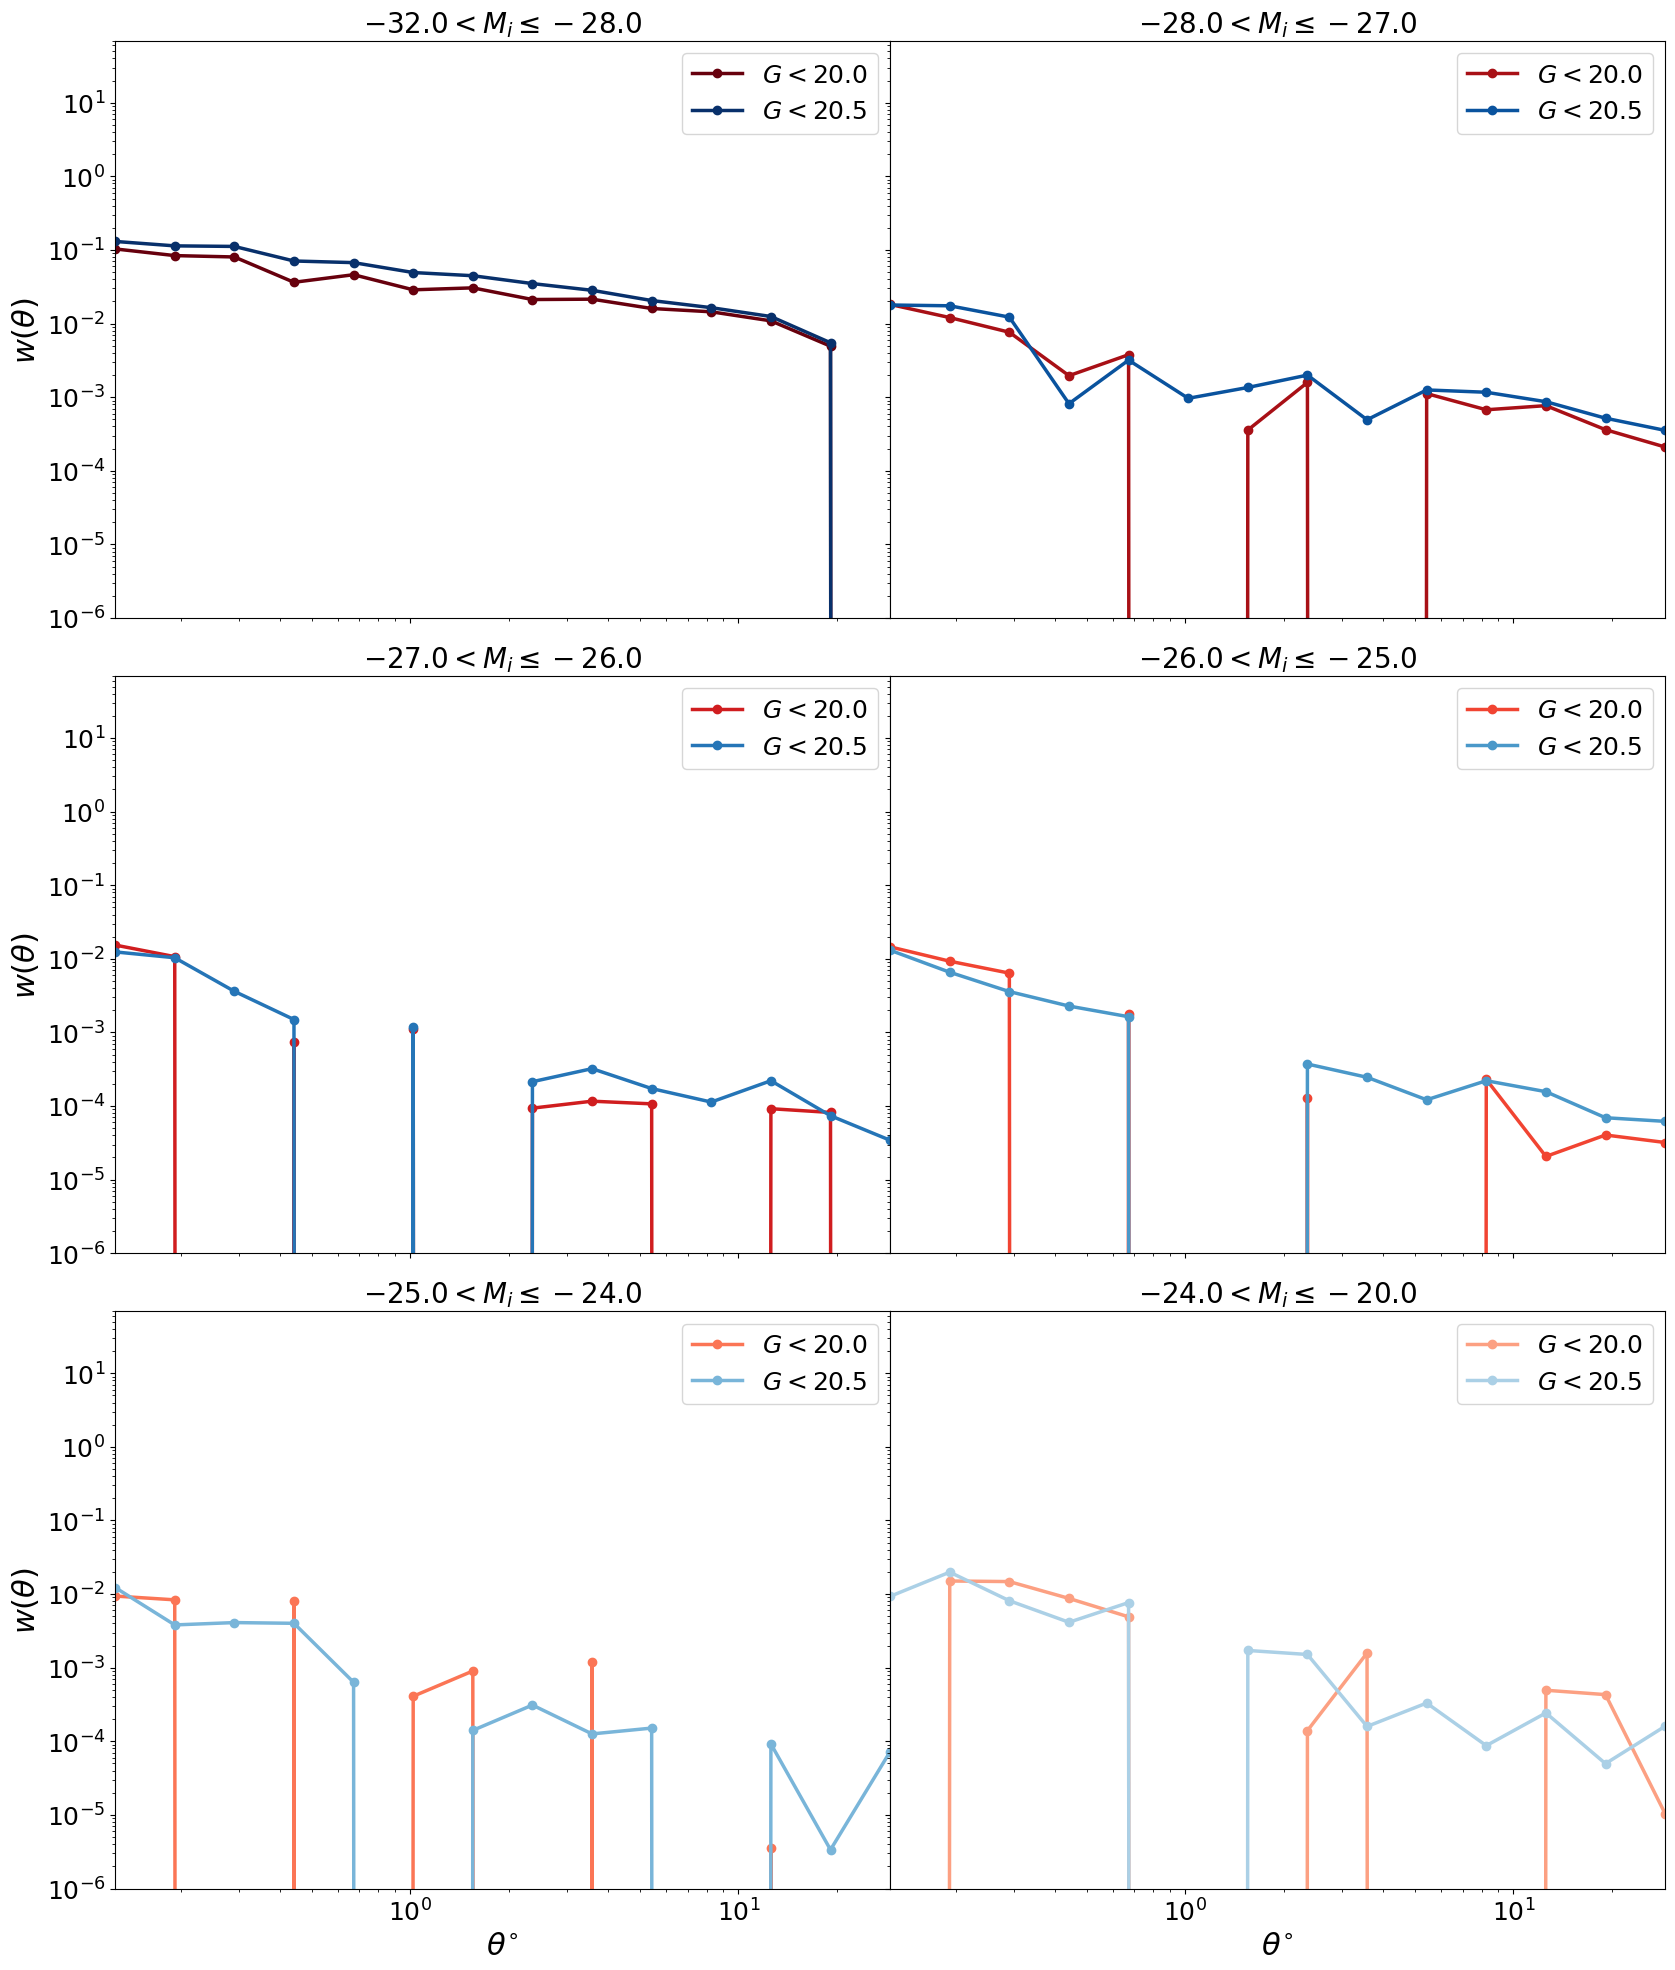

In [44]:
# plot!
fig = plt.figure(figsize = (col*10, row*8))
gs = gridspec.GridSpec(row, col, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(quaia.recenter(thetabins), wtheta[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
    ax1.set_ylim(1e-6, 7e1)
    ax1.legend()
    if Lbin>(np.max(L_array)-col):
        ax1.set_xlabel(r'$\theta^{\circ}$')
    else:
        ax1.set_xticklabels([])
    if Lbin%col==0:
        ax1.set_ylabel(r"$w(\theta)$")
    else:
        ax1.set_yticklabels([])

plt.show()